# CNN for GI Disease Classification + Disease Correlation Analysis

**Authors**: Mohammed Musaddiq Vavartar, Vishakha Kamothi, Bhuvanesh Kantamuneni, Afshaan Fathima Syeda

**Course**: CSC 483 – Applied Deep Learning

**Description**: In this project, we have developed a deep learning pipeline to classify GI endoscopy images and analyze disease correlations. It contains a CNN architecture built from scratch and trained on a clinically diverse dataset, fed into the CNN using a custom data generator. After validating the model’s performance, the extracted feature embeddings are used to predict additional clinical findings such as H. pylori infection and pre-pyloric ulcers. Finally, I performed co-occurrence and correlation analysis to uncover relationships between GI diseases anatomical labels.

In [1]:
!cp -r "/content/drive/MyDrive/aaaaaaafinal_project/Labeled Images" "/content/Labeled_Images"


# Libraries & Introduction

We will import libraries needed throughout the project.

*   `NumPy & Pandas` : used for numerical operations, reading CSV files, and handle dataset.
*   `PIL` : for loading and resizing images.

*   `keras.layers` : used for basic blocks for our CNN like Conv2D, MaxPooling, Dense etc..
*   `keras.models` : used for sequential model for our CNN.
*   `keras.optimizers` : providing optimization "Adam" to update model weights for training.
*   `keras.regularizers` : using L2 tyring to prevent overfitting
*   `keras.callbacks` :used for EarlyStopping and ModelCheckpoint to stop bad training early, mainly to save the best model.
*   `keras.utils` : used for tools such as converting labels to one-hot encodings and random seeds.


*   `scikit-learn` : used for splitting data, computing class weights, evaluating model performance
*   `scikit-learn.LabelEncoder` : used to convert anatomical labels like 'A6, G2' to integer
*   `scikit-learn.metrices` : used for evaluation tools like accuracy, F1 score, AUC

*   `matplotlib` : used for visualizing and plots such as label distribution, training curves
*   `seaborn` : used for heatmap in confusion matrix

*   `json` : used to load metadata file

*   `scikit_learn.linear_model` : used for satistic model for correlation ( logistic regression algo)

*   `scikit-learn.metrices.roc_auc_score` : used to calculate auc score

Since google colab limited runtime session, seed is fixed so that the result are consistant when they are executed again incase of session timeout.



In [2]:
import os
import numpy as np
import pandas as pd
import math
import keras

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)
from PIL import Image
from keras import layers, models, optimizers, regularizers, utils, losses, metrics, callbacks
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.utils import Sequence as KerasSequence, to_categorical


import matplotlib.pyplot as plt
import seaborn as sns

import json
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score


#fixing to 42 to so that train/val/test splits and model outputs remain some what consistent.
SEED = 42
# why 42 -> it was commonly used in reference we refered
keras.utils.set_random_seed(SEED)
np.random.seed(SEED)


# Path & loading Dataset, Metadata

we have specified project directory/path for 2 purposes:


*   Load Dataset and Metadata ` image_classification.csv ` which has image filenames, patient IDs, and their manually-verified GI disease labels (FG agreement).


*   To store confusion matrix and resulting classification csv files





In [3]:
project_directory = '/content/drive/MyDrive/aaaaaaafinal_project'
Image_directory   = '/content/Labeled_Images'
#os.path.join(project_directory, 'Labeled Images')
csv_file          = os.path.join(project_directory, 'splits', 'image_classification.csv')

#IMPORTANT TEAM MEMBERS: project directory to be changed accordingly
print("Project dir:", project_directory)
#same as above , change it
print("Image dir:", Image_directory)
#the image classification file
print("CSV file:", csv_file)

# dataframes
df = pd.read_csv(csv_file)
df.columns = df.columns.str.strip()
print("Columns:", df.columns.tolist())
print("Total rows in CSV:", len(df))

Project dir: /content/drive/MyDrive/aaaaaaafinal_project
Image dir: /content/Labeled_Images
CSV file: /content/drive/MyDrive/aaaaaaafinal_project/splits/image_classification.csv
Columns: ['Unnamed: 0', 'num patient', 'filename', 'FG1 (Team A)', 'FG2 (Team A)', 'G1 (Team B)', 'G2 (Team B)', 'Complete agreement', 'Triple agreement', 'FG agreement', 'G agreement', 'FG1-G1 agreement', 'FG1-G2 agreement', 'FG2-G1 agreement', 'FG2-G2 agreement', 'set_type']
Total rows in CSV: 8834


# Cleaning Labels & Train/Val/Test Split



*   Remove entries with missing labels
*   using LabelEncoder to number the labels form 'A6', 'G2' etc..


*   Split dataset into:

        70% training

        15% validation

        15% testing





In [4]:
# anatomical label column
target_col = 'FG agreement'
# label's corresponding image filename
img_col     = 'filename'

#dropping rows with no labels ( missing )
df = df.dropna(subset=[target_col]).copy()
print("After dropping rows with missing label:", len(df))

def build_filepath(row):
    fn = str(row[img_col])
    # labeled images are direct
    direct = os.path.join(Image_directory, fn)
    # in subfolder
    sub_direct = os.path.join(Image_directory, str(row['num patient']), fn)

    if os.path.exists(direct):
        return direct
    if os.path.exists(sub_direct):
        return sub_direct


    return direct

df['filepath'] = df.apply(build_filepath, axis=1)
df['exists']   = df['filepath'].apply(os.path.exists)

print("Rows where image file exists:", df['exists'].sum())
print("Rows where image file is missing:", (~df['exists']).sum())

#keeping rows with correct file only
df = df[df['exists']].copy()
df = df.drop(columns=['exists'])

print("Finally the usable rows are (with image files):", len(df))

if len(df) == 0:
    raise RuntimeError("No images found for any CSV rows. Check folder paths.")

After dropping rows with missing label: 6126
Rows where image file exists: 6126
Rows where image file is missing: 0
Finally the usable rows are (with image files): 6126


In [5]:
#label encoding
# labels are made into integers
le = LabelEncoder()
df['label'] = le.fit_transform(df[target_col].astype(str))

# assigning the taken seed
seed_v = SEED

#counts and class variables
class_names = list(le.classes_)
num_classes = len(class_names)
label_map = {cls: idx for idx, cls in enumerate(le.classes_)}

print("the anatomical labels are :", class_names)
print("total no. of label/classes:", num_classes)

# spliting the total dataset into 70% for training & 30% is kept as temp
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=seed_v,
    stratify=df['label']
) # the temporary 30% is divided 50-50 for 15% validation & 15% testing
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=seed_v,
    stratify=temp_df['label']
)

print("size used for training:", len(train_df))
print("size of validation:", len(val_df))
print("size used for testing:", len(test_df))

the anatomical labels are : ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'G1', 'G2', 'G3', 'G4', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6', 'OTHERCLASS', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6']
total no. of label/classes: 23
size used for training: 4288
size of validation: 919
size used for testing: 919


# Visualize Label Distribution

To get a better understanding of how many images exist for each GI disease label

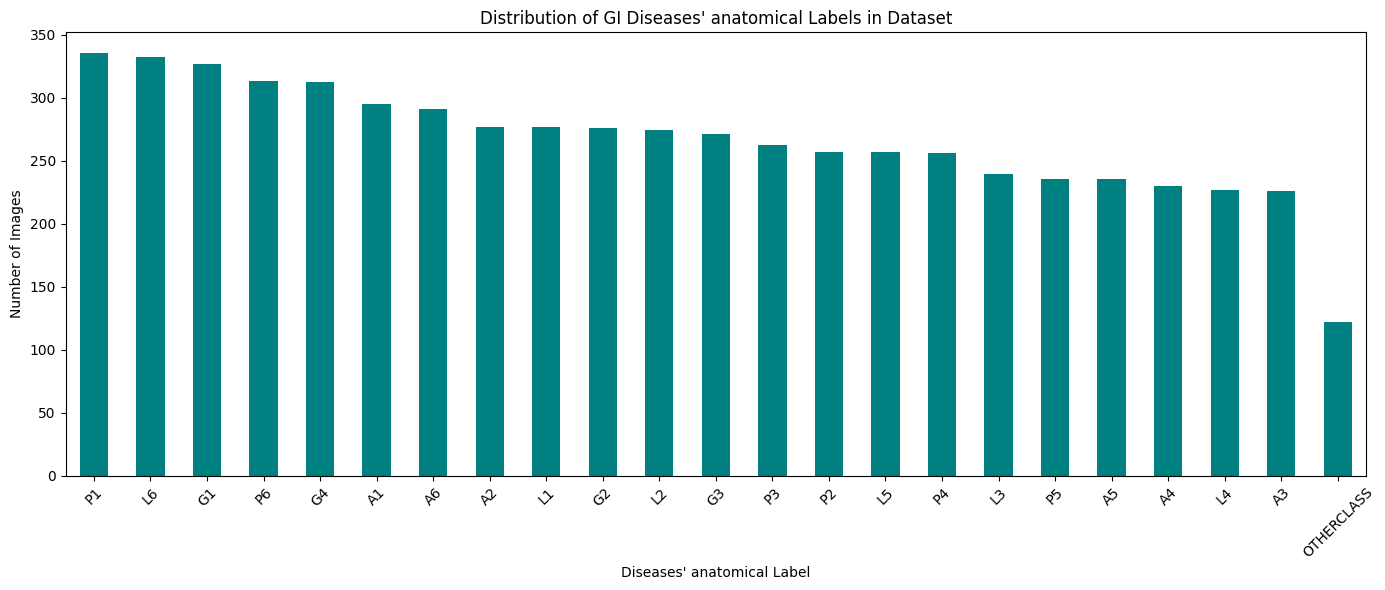

In [6]:
#plotting the size of all labels and the no. of images it has
plt.figure(figsize=(14, 6))
df['FG agreement'].value_counts().plot(kind='bar', color='teal')
# used to showing the imabalance between each labels
plt.title("Distribution of GI Diseases' anatomical Labels in Dataset")
#x axis si labels
plt.xlabel("Diseases' anatomical Label")
# y axis is images size
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Data generator

We are using Keras Sequence to pass data for training in batch size for training. The main idea behind this to give batch wise rather than giving it all at once.



*   loads images with PIL
*   resizes to (224, 224)
*   normalizes pixel values to [0,1]
*  applies basic augmentation (
*  caches batches in memory for faster epoch time
*  returns (X_batch, y_one_hot)



In [7]:

image_size   = (224, 224)
# batch size passed to data generator
batch_size   = 32
#Note to self: can be removed redundant
NUM_CLASSES  = num_classes

def load_image(path, label):
    #using PIL and Numpy to load images
    try:
        img = Image.open(path).convert('RGB')
        img = img.resize(image_size)
        img = np.array(img, dtype=np.float32) / 255.0
        return img, label
    except Exception as e:
        print(f"I think the path doesnt exist : {path}: {e}")
        return np.zeros((*image_size, 3), dtype=np.float32), label

# main part -> I made a data genertor to feed data as batches to the CNN to avoid previous memory error I faced while loading images
class Data_genertr(KerasSequence):
  # constructor
    def __init__(self, df, image_dir, batch_size, target_size, n_classes, label_map_dict,
                 shuffle=True, augmentations=False, cache_batches=True):
      # dataframe , filepath & labels
        self.df = df
        # folder that has images
        self.image_dir = image_dir
        # batch size samples
        self.batch_size = batch_size
        # 224 x 224
        self.target_size = target_size
        #the 23 number of labels classes
        self.n_classes = n_classes
        #shuffling dataset for each epoch
        self.shuffle = shuffle
        self.augmentations = augmentations
        #caching batches for speeding up
        self.cache_batches = cache_batches

# labels to int
        self.df['label_encoded'] = self.df[target_col].map(label_map_dict)
        # shuffling index array we are using
        self.indices = np.arange(len(self.df))
        self.batch_cache = {}
        self.on_epoch_end()
#  no. of batches per epoch
    def __len__(self):
        return math.ceil(len(self.df) / self.batch_size)
# shuffling index order
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)
# using the cache items to reuse
    def __getitem__(self, index):
        if self.cache_batches and index in self.batch_cache:
            X, y = self.batch_cache[index]
        else:
            indices = self.indices[index * self.batch_size: (index + 1) * self.batch_size]
            # images & its labels are alloccated to array
            X = np.empty((len(indices), *self.target_size, 3), dtype=np.float32)
            y = np.empty((len(indices)), dtype=int)
# looping through each image file
            for i, idx in enumerate(indices):
                img_path = self.df.iloc[idx]['filepath']
                img, _ = load_image(img_path, self.df.iloc[idx]['label_encoded'])
                label_int = self.df.iloc[idx]['label_encoded']
# augmentation flip
                if self.augmentations and np.random.rand() < 0.5:
                    img = np.flip(img, axis=1)

                X[i] = img
                y[i] = label_int
# int labels to onehot
            y = utils.to_categorical(y, num_classes=self.n_classes)
            # storing batch in cache
            if self.cache_batches:
                self.batch_cache[index] = (X, y)

        return X, y


# Instantiate Generators


train_generator = Data_genertr(
    train_df, Image_directory, batch_size, image_size, NUM_CLASSES, label_map,
    shuffle=True, augmentations=True, cache_batches=True
)

val_generator = Data_genertr(
    val_df, Image_directory, batch_size, image_size, NUM_CLASSES, label_map,
    shuffle=False, augmentations=False, cache_batches=True
)

test_generator = Data_genertr(
    test_df, Image_directory, batch_size, image_size, NUM_CLASSES, label_map,
    shuffle=False, augmentations=False, cache_batches=True
)

print("\nData Generators instantiation done :)")





Data Generators instantiation done :)


# Building CNN

we have build a 5 block Convolutional Neural Network.


1.   filters are started from 32 -> 64 -> 128 -> 256 -> 512.
2.   Two conv layers per block

1.   MaxPooling to reduce spatial size



1.   Dropout + L2 regularization to reduce overfitting



2.   at last from Dense(512)->  Dense(256)->  Softmax output





In [8]:
def deep5_cnn(input_shape=(224, 224, 3), num_classes=NUM_CLASSES):
    L2 = regularizers.l2(1e-4)

    model = models.Sequential()

    # block 1
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=L2, input_shape=input_shape))
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=L2))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.2))

    #Block 2
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=L2))
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=L2))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    #block 3
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=L2))
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=L2))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.3))

    #block 4
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=L2))
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=L2))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.35))

    #  block 5
    model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=L2))
    model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=L2))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.4))

    #Dense Layers
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu', kernel_regularizer=L2))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(256, activation='relu', kernel_regularizer=L2))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

model = deep5_cnn()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             

 Total params: 17,695,031 (67.50 MB)

 Trainable params: 17,695,031 (67.50 MB)

 Non-trainable params: 0 (0.00 B)

Part of data pre processing:



*   the weight of each class labels are calculated.



In [9]:

class_weight_values = compute_class_weight(
    class_weight='balanced',
    # unique labels ( 0 -22 & otherclass)
    classes=np.unique(df['label']),
    #freq of label images
    y=df['label']
)

class_weight_dict = {i: w for i, w in enumerate(class_weight_values)}

# Training Section



*   hyperparameters are defined,
*   optimizer used: `Adam` because Adam seems to adapt learning rate better than SGD with learning rate `1e-4`.


*   Since we have multi class(labels) we use Categorical Crossentropy, which measures how well the predicted probability distribution matches the true label.
*   patience is set to 25 to give enough time/room to improve without stopping early. When validation loss is not improving for the time defined we use early stopping to make sure it does ovetfit and time saving.


*   ModelCheckpoint saves the best version of the model during training so we don't use a worse-performing epoch










In [10]:
if num_classes == 2:
    #binary classification:
    loss_fn = losses.BinaryCrossentropy()
    metrics_list = ['accuracy', metrics.AUC(name='auc')]
else:
    # Multi-class classification:
    # one-hot labels are generated which is used by CategoricalCrossentropy
    loss_fn = losses.CategoricalCrossentropy()
    metrics_list = ['accuracy']

#Model Compilation

print("\n*** Starting Model Compilation ***")

model.compile(

    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=loss_fn,
    metrics=metrics_list
)
# IMP:
#callbacks and Training

#wont reach 75 as early stopping is used
EPOCHS = 75


callbacks_list = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=25,
        restore_best_weights=True
    ),
    callbacks.ModelCheckpoint(

        filepath=os.path.join(project_directory, 'simple_cnn_best.keras'),
        monitor='val_loss',
        save_best_only=True,

    )
]

print("\n*** Starting Compliance CNN Training ***")
#model
history = model.fit(

    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks_list
)

# this loads the best weights saved by the callback
model.load_weights(os.path.join(project_directory, 'simple_cnn_best.keras'))
print("\nCompliance Model training complete and best weights loaded.")


*** Starting Model Compilation ***

*** Starting Compliance CNN Training ***


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/75
134/134 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.0477 - loss: 3.3930 - val_accuracy: 0.1045 - val_loss: 3.3215
Epoch 2/75
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.1104 - loss: 3.1952 - val_accuracy: 0.1502 - val_loss: 3.0239
Epoch 3/75
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.1446 - loss: 2.9994 - val_accuracy: 0.2122 - val_loss: 2.7958
Epoch 4/75
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.1765 - loss: 2.7907 - val_accuracy: 0.2633 - val_loss: 2.5510
Epoch 5/75
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.2518 - loss: 2.5219 - val_accuracy: 0.3526 - val_loss: 2.2855
Epoch 6/75
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.2946 - loss: 2.3167 - val_accuracy: 0.3787 - val_loss: 2.1262
Epoch 7/75
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.3584 - loss: 2.1900 - val_accuracy: 0.4353 - val_loss: 1.9749
Epoch 8/75
134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.3763 - loss: 2.0970 - val_accu

# Plot Learning Curves

we plot


* Training vs Validation Loss


*  Training vs Validation Accuracy






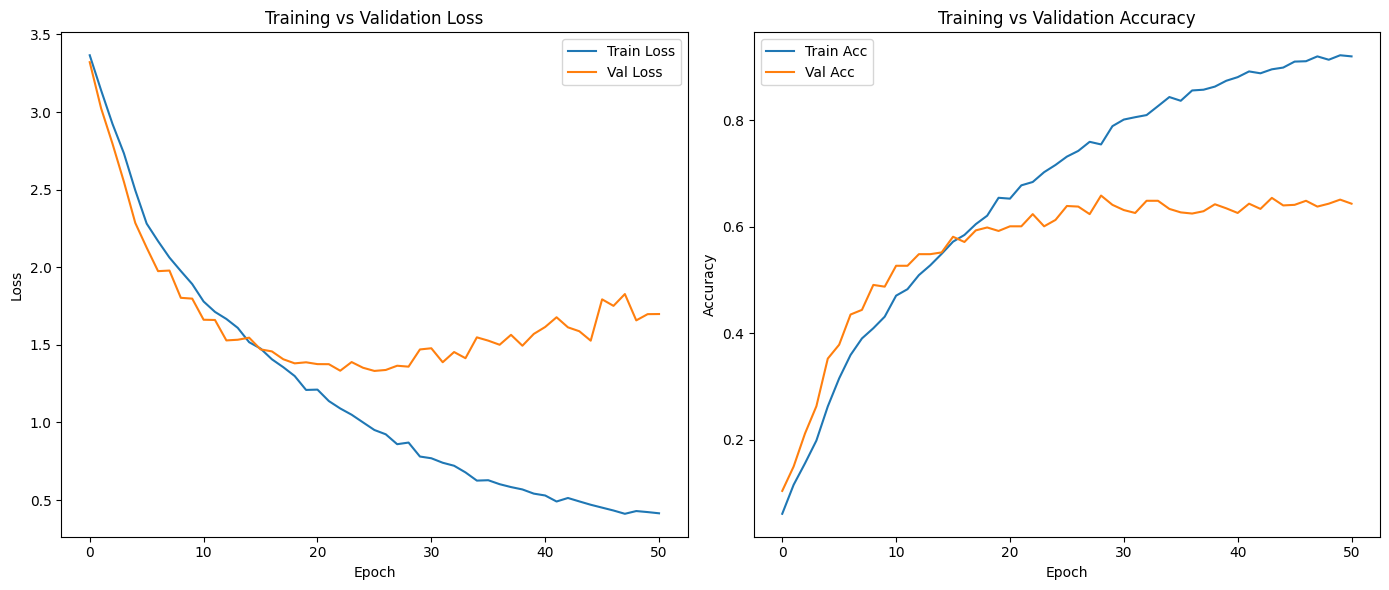

In [11]:

#Graph: Training Curves


plt.figure(figsize=(14,6))

#Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Training vs Validation Loss")
# x axis is training loss
plt.xlabel("Epoch")
# y. axis is val loss
plt.ylabel("Loss")
plt.legend()

# accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Training vs Validation Accuracy")
# xaxis is epoch training accuracy
plt.xlabel("Epoch")
# y axis is val accuracy
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


# Test Section

we try the trained model on un seen test set.

the metrices we take are:


*   Accuracy ( shows overall percentage of correct classified images )
*   Weighted Precision ( shows models positive predictions and accounting imbalance )



*   Weighted Recall ( shows true disease cases the model successfully detects, by frequency )
*   F1-score ( we used this to balance precision incase inbalance exist)



*   MCC ( shows performance even with highly imbalanced GI disease labels)



---




1. **Confusion Matrix:** visually shows which diseases the model confuses, we used to understand and identify overlapping classes.
2.  **CSV Classification Report:**  a detailed csv file for each disease class







** Evaluting test  ***
29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 724ms/step
Accuracy (overall): 0.6496
Weighted Precision (prob): 0.6685
Weighted Recall: 0.6496
Weighted F1-score: 0.6505
Matthews Correlation Coefficient (MCC): 0.6341

Classification report saved to: /content/drive/MyDrive/aaaaaaafinal_project/cnn_classification_report.csv

 the saved classification Report:
              precision    recall  f1-score   support

          A1       0.60      0.73      0.66        44
          A2       0.45      0.54      0.49        41
          A3       0.69      0.59      0.63        34
          A4       0.68      0.54      0.60        35
          A5       0.57      0.77      0.66        35
          A6       0.71      0.93      0.81        43
          G1       0.91      0.65      0.76        49
          G2       0.43      0.76      0.55        42
          G3       0.62      0.59      0.60        41
          G4       0.82      0.70      0.76        47
          L1       0.74      0.78      

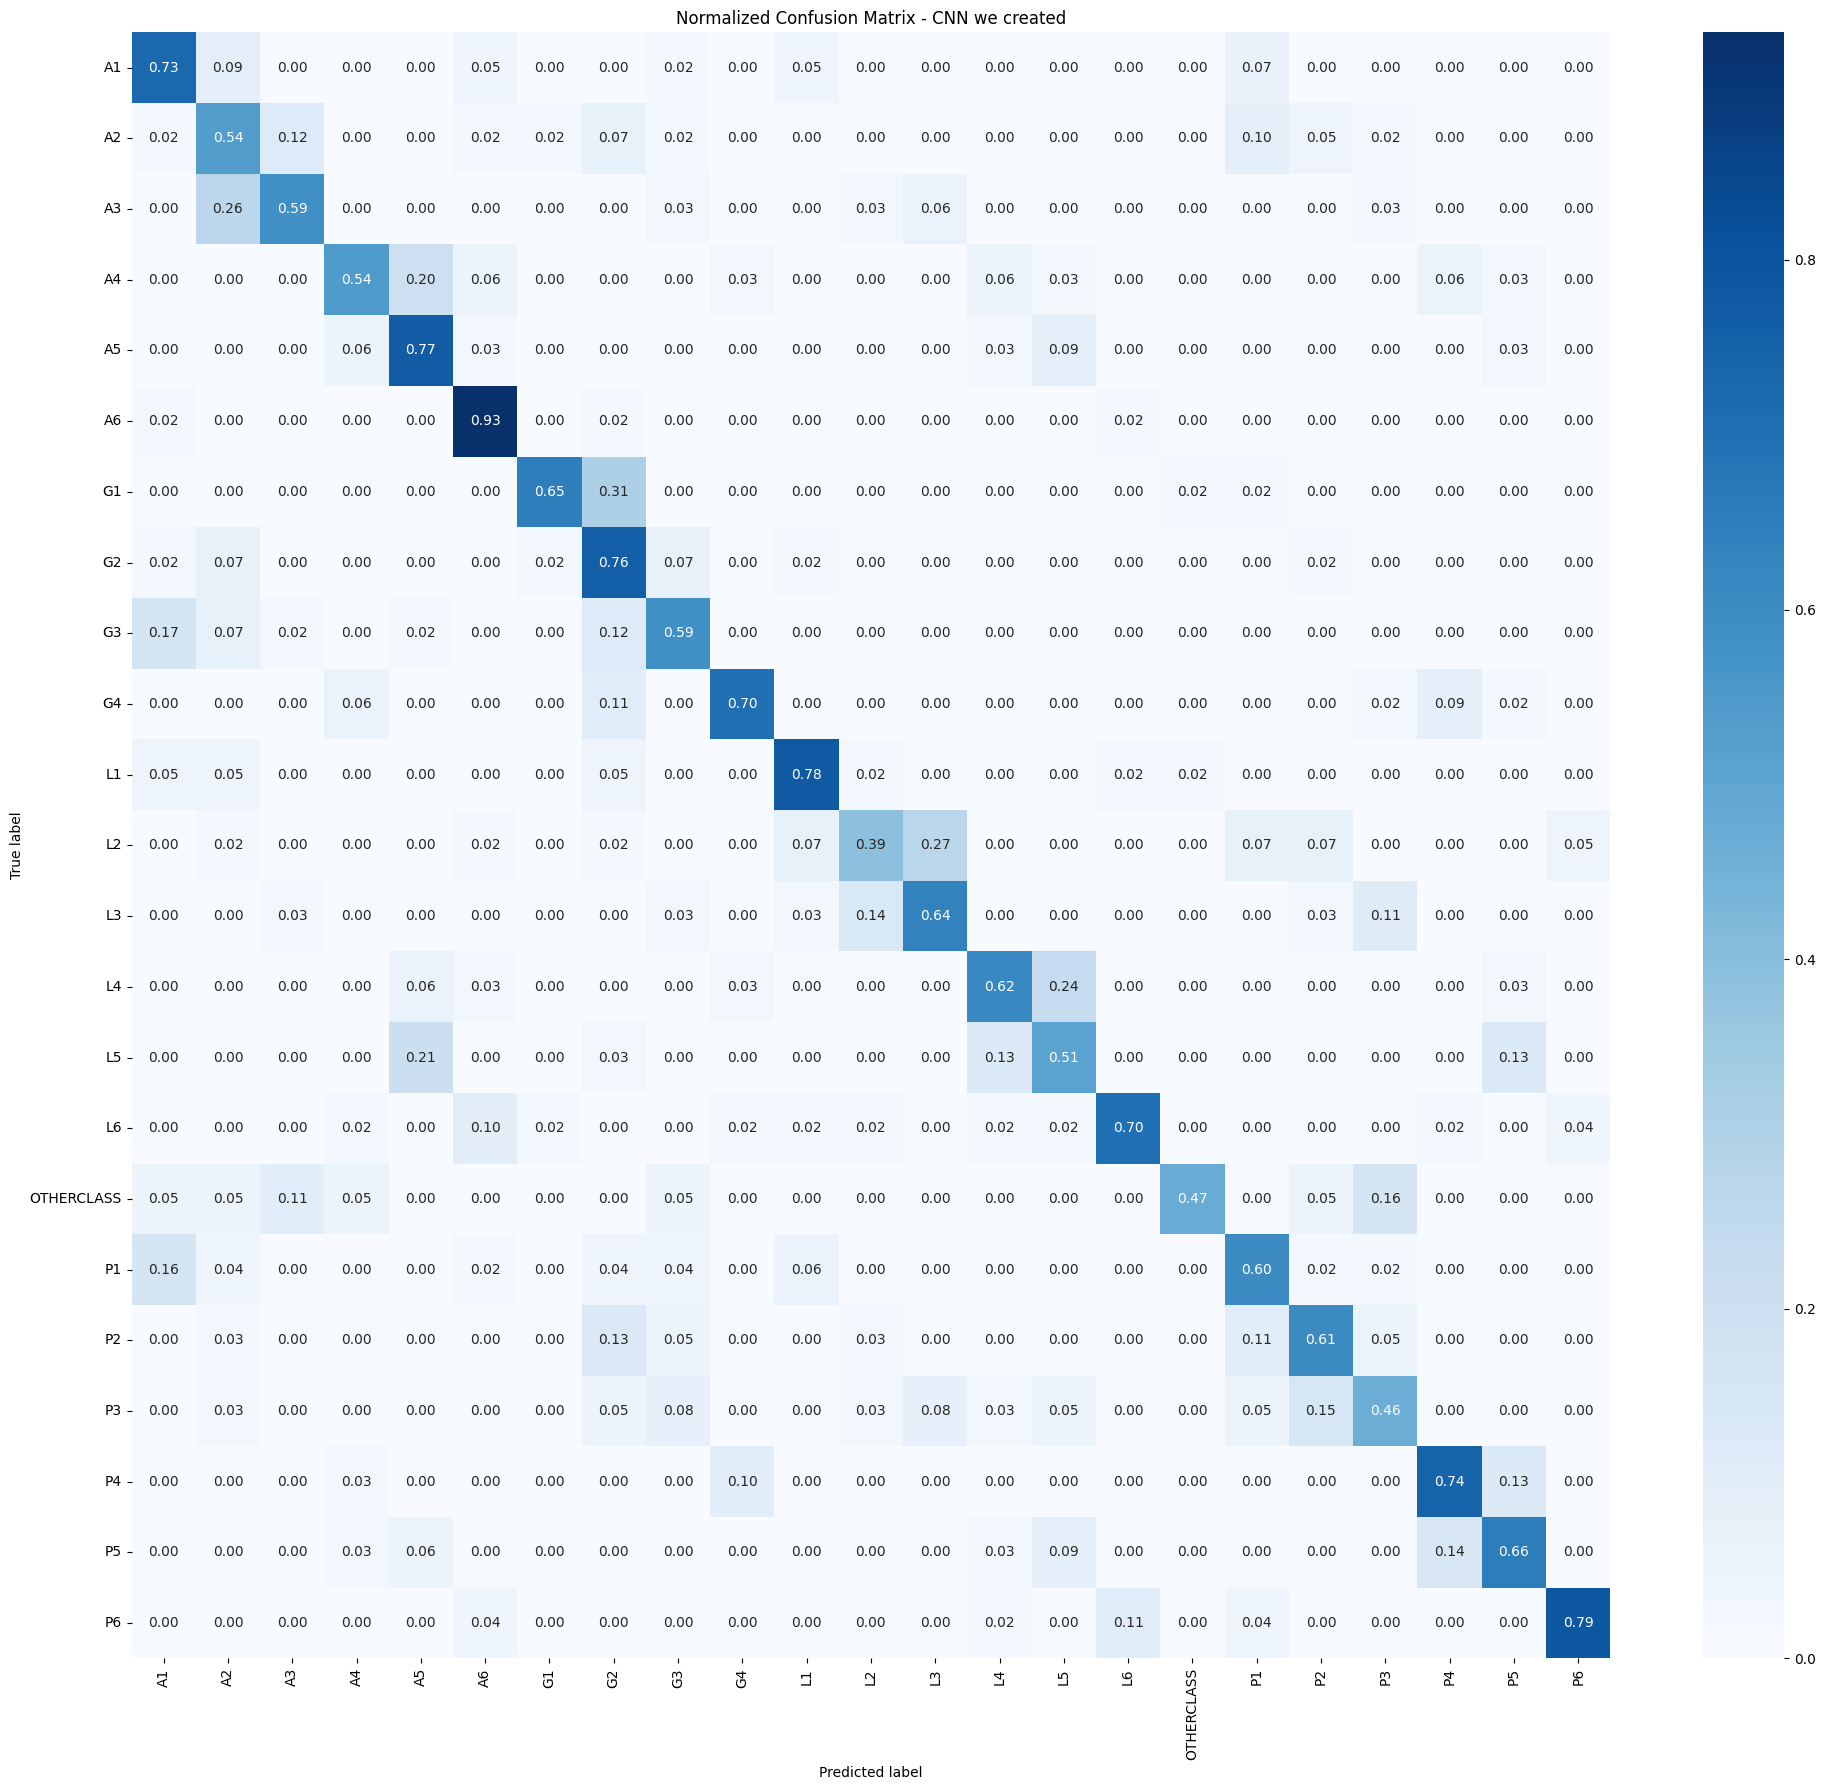

Confusion matrix image saved to: /content/drive/MyDrive/aaaaaaafinal_project/confusion_matrix_cnn.png


In [12]:
#Final full detailed testing, report, confusing matrix

print("\n** Evaluting test  ***")

# getting true labels from test_df
#this allings with test_ds
y_true = test_df['label'].values

#prediction
 # getting probabilites basically
y_prob = model.predict(test_generator)

if num_classes == 2:
    y_prob_flat = y_prob.ravel()
    y_pred = (y_prob_flat >= 0.5).astype(int)
else:
    y_pred = np.argmax(y_prob, axis=1)

# metrices
acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted', zero_division=0
)
mcc = matthews_corrcoef(y_true, y_pred)

print(f"Accuracy (overall): {acc:.4f}")
print(f"Weighted Precision (prob): {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1-score: {f1:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}\n")

# report of classification is made
target_names = class_names
report = classification_report(
    y_true, y_pred, target_names=target_names, zero_division=0, output_dict=True
)

report_df = pd.DataFrame(report).transpose()
report_path = os.path.join(project_directory, 'cnn_classification_report.csv')
report_df.to_csv(report_path)
print("Classification report saved to:", report_path)

print("\n the saved classification Report:")
print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))

#confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

#heatmap to show how each labels are confused by one and other
plt.figure(figsize=(20, 18))
sns.heatmap(
    #standard values
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title('Normalized Confusion Matrix - CNN we created')
# true labels from test_df is used here
plt.ylabel('True label')
# the predicted probabilities are used here
plt.xlabel('Predicted label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

cm_path = os.path.join(project_directory, 'confusion_matrix_cnn.png')
plt.savefig(cm_path)
plt.show()

print("Confusion matrix image saved to:", cm_path)

# AUC Analysis

we used this to show which diseases the CNN can distinguish most reliably by one vs Rest format.

In [13]:
from sklearn.metrics import roc_auc_score

print("\n Calculating Individual One-vs-Rest (OvR) AUC Scores")

# the one vs Rest  AUC score for each class separately
individual_auc_scores = roc_auc_score(
    y_true,
    y_prob,
    multi_class='ovr',
    # to get scores of all classes , avg is None
    average=None
)

# simple dataFrame to display the results nicely
auc_report_df = pd.DataFrame({
    'Anatomical Site': class_names,
    'OvR AUC Score': individual_auc_scores
})

#sorting the displaying the result from top scores to low
auc_report_df = auc_report_df.sort_values(by='OvR AUC Score', ascending=False).reset_index(drop=True)

print("\n## Created Model's Distinguising scores (AUC per Class) ##")
print(auc_report_df.to_markdown(index=False, numalign="left", stralign="left"))
print(" ----------------------------------------------------------\n")


 Calculating Individual One-vs-Rest (OvR) AUC Scores

## Created Model's Distinguising scores (AUC per Class) ##
| Anatomical Site   | OvR AUC Score   |
|:------------------|:----------------|
| A6                | 0.994876        |
| G1                | 0.987638        |
| L1                | 0.986749        |
| A3                | 0.985444        |
| P4                | 0.983042        |
| P5                | 0.982094        |
| L3                | 0.981943        |
| A4                | 0.980963        |
| A5                | 0.980511        |
| P6                | 0.976771        |
| L6                | 0.97618         |
| L5                | 0.9713          |
| L4                | 0.967365        |
| G2                | 0.962643        |
| G4                | 0.959667        |
| P1                | 0.958872        |
| P2                | 0.9586          |
| A1                | 0.957195        |
| L2                | 0.951608        |
| P3                | 0.941579        |
| G3  

# Diseases' anatomical labels Co-Occurrence Analysis

we found Co-occurrence counts meaning which diseases' anatomical labels appear together most by finding **Co-occurrence matrix**  it counts how many patients can have both A and B at the same time.

Pearson correlation  how strongly two diseases are related stats wise ( correlation (between 1 and +1) for each pair.

*   +1.0  always appear together
*   0.0  unrelated


*   -1.0  never appear together

In [14]:
print("\n--- labels Co-Occurrence ---")

# set contains the patient total with diseases
patient_disease_sets = (
    df.groupby('num patient')['label']
      .apply(lambda s: set(s.tolist()))
)

print("Total patients:", len(patient_disease_sets))

num_classes = len(class_names)
co_occ = np.zeros((num_classes, num_classes), dtype=int)

#co-occurrence is calculated
for dset in patient_disease_sets:
    dlist = list(dset)
    for i in range(len(dlist)):
        for j in range(len(dlist)):
            co_occ[dlist[i], dlist[j]] += 1

#dataframe of the above
co_occ_df = pd.DataFrame(co_occ, index=class_names, columns=class_names)

print("\nTop Co-occurrence Examples:")
for i, cname in enumerate(class_names):
    row = co_occ_df.iloc[i].copy()
    #ignoring self
    row[i] = 0
    top = row.sort_values(ascending=False).head(1)
    print(f"  {cname} → {top.index[0]} (co-occur count = {top.values[0]})")



--- labels Co-Occurrence ---
Total patients: 387

Top Co-occurrence Examples:
  A1 → G1 (co-occur count = 250)
  A2 → L6 (co-occur count = 223)
  A3 → L6 (co-occur count = 198)
  A4 → L6 (co-occur count = 191)
  A5 → L5 (co-occur count = 206)
  A6 → L6 (co-occur count = 278)
  G1 → P1 (co-occur count = 267)
  G2 → P1 (co-occur count = 226)
  G3 → L6 (co-occur count = 224)
  G4 → L6 (co-occur count = 237)
  L1 → P1 (co-occur count = 242)
  L2 → L6 (co-occur count = 228)
  L3 → P3 (co-occur count = 203)
  L4 → L6 (co-occur count = 196)
  L5 → L6 (co-occur count = 222)
  L6 → P6 (co-occur count = 288)
  OTHERCLASS → L6 (co-occur count = 56)
  P1 → G1 (co-occur count = 267)
  P2 → P1 (co-occur count = 222)
  P3 → L6 (co-occur count = 226)
  P4 → L6 (co-occur count = 218)
  P5 → L6 (co-occur count = 204)
  P6 → L6 (co-occur count = 288)


/tmp/ipython-input-2480369547.py:28: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  row[i] = 0


In [15]:
print("\n--- Co-occurrence Correlation for All labels ---")

#set of unique diseases
patient_disease_sets = (
    df.groupby('num patient')['label']
      .apply(lambda s: set(s.tolist()))
)

class_index = {cls: i for i, cls in enumerate(class_names)}
num_classes = len(class_names)
num_patients = len(patient_disease_sets)

#the disease we are trying to detect using binary

presence = np.zeros((num_patients, num_classes), dtype=int)
patient_ids = list(patient_disease_sets.index)

for p_idx, pid in enumerate(patient_ids):
    for lbl in patient_disease_sets[pid]:
        presence[p_idx, lbl] = 1

presence_df = pd.DataFrame(
    presence,
    columns=class_names,
    index=patient_ids
)

#correlations between diseases
corr_df = presence_df.corr(method='pearson')

#making a function to print top correlated diseases
def print_top_corr(disease, top_k=3):
    if disease not in corr_df.columns:
        print(f"ERROR: {disease} not found in labels.")
        return

    row = corr_df.loc[disease].copy()
    # this will make sure it will exclude itself
    row[disease] = -1

    top = row.sort_values(ascending=False).head(top_k)

    print(f"\n{disease} — Top {top_k} correlated labels:")
    for d, val in top.items():
        print(f"  → {d} (corr ≈ {val:.2f})")

#func call which will print all
for disease in class_names:
    print_top_corr(disease, top_k=3)



--- Co-occurrence Correlation for All labels ---

A1 — Top 3 correlated labels:
  → G1 (corr ≈ 0.35)
  → L1 (corr ≈ 0.34)
  → P1 (corr ≈ 0.18)

A2 — Top 3 correlated labels:
  → G2 (corr ≈ 0.40)
  → L2 (corr ≈ 0.39)
  → P2 (corr ≈ 0.33)

A3 — Top 3 correlated labels:
  → L3 (corr ≈ 0.55)
  → G3 (corr ≈ 0.46)
  → P3 (corr ≈ 0.41)

A4 — Top 3 correlated labels:
  → G4 (corr ≈ 0.36)
  → L4 (corr ≈ 0.31)
  → A5 (corr ≈ 0.27)

A5 — Top 3 correlated labels:
  → L5 (corr ≈ 0.59)
  → P5 (corr ≈ 0.33)
  → A4 (corr ≈ 0.27)

A6 — Top 3 correlated labels:
  → L6 (corr ≈ 0.58)
  → P6 (corr ≈ 0.47)
  → P3 (corr ≈ 0.14)

G1 — Top 3 correlated labels:
  → A1 (corr ≈ 0.35)
  → P1 (corr ≈ 0.31)
  → L1 (corr ≈ 0.20)

G2 — Top 3 correlated labels:
  → A2 (corr ≈ 0.40)
  → P2 (corr ≈ 0.36)
  → P3 (corr ≈ 0.27)

G3 — Top 3 correlated labels:
  → A3 (corr ≈ 0.46)
  → L3 (corr ≈ 0.40)
  → P3 (corr ≈ 0.39)

G4 — Top 3 correlated labels:
  → A4 (corr ≈ 0.36)
  → P4 (corr ≈ 0.20)
  → P5 (corr ≈ 0.18)

L1 — Top 

#Feature Extraction

For each image, we extract a 256-dimensional embedding and save it as `all_image_features.csv `.

the embedding contains representation of GI label/tissue appearance which was learned by the model



In [16]:
print("\n** Extracting CNN Features ***")


#Here we are using the already trainied but just in case a safety no-op
_ = model.predict(np.zeros((1, *image_size, 3), dtype=np.float32))

#building a feature extraction model that reuses all layers except the final softmax
#last layers are ... Dense(512) → Dropout → Dense(256) → Dropout → Dense(num_classes)


#    model.layers[-1] is the softmax head, so we drop it.
feature_model = keras.models.Sequential(model.layers[:-1])

#generator for the dataset simple no augmentation used
all_df = df.sort_values(['num patient']).reset_index(drop=True)

all_generator = Data_genertr(
    all_df,
    Image_directory,
    batch_size=batch_size,
    target_size=image_size,
    n_classes=NUM_CLASSES,
    label_map_dict=label_map,
    shuffle=False,
    augmentations=False,
    cache_batches=False
)

#extracting features
features = feature_model.predict(all_generator)
print("Feature shape:", features.shape)

#saving as CSV
feature_dim = features.shape[1]
feat_cols = [f"feature_{i}" for i in range(feature_dim)]

df_features = pd.DataFrame(features, columns=feat_cols)
df_features['num patient'] = all_df['num patient'].values

save_path = os.path.join(project_directory, "all_image_features.csv")
df_features.to_csv(save_path, index=False)

print("Saved:", save_path)



** Extracting CNN Features ***
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


192/192 ━━━━━━━━━━━━━━━━━━━━ 138s 715ms/step
Feature shape: (6126, 256)
Saved: /content/drive/MyDrive/aaaaaaafinal_project/all_image_features.csv


# Binary Prediction for Diseases

Using embeddings + metadata `gastrohun-videoendoscopy-metadata.json`
we predict two diseases using Logistic Regression:

1. H. Pylori Infection

2. Pre-pyloric Ulcer



---
* what we did here is merge features embedding we got with metadata and then created cleaned binary labels, then train ML classifier

* to test we used AUROC and Average Precision




In [17]:
import json
import pandas as pd
import numpy as np
import os
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, average_precision_score

print("\n Binary Disease detection  (H. Pylori + Pre-pyloric Ulcer)")


#Loading the CNN features vector we calculated from the above block

FEATURE_FILE = os.path.join(project_directory, "all_image_features.csv")
df_features = pd.read_csv(FEATURE_FILE)
df_features['num patient'] = df_features['num patient'].astype(str)

print("Loaded features:", df_features.shape)


#the metadata json file

META_FILE = os.path.join(project_directory, "gastrohun-videoendoscopy-metadata.json")

with open(META_FILE, "r") as f:
    meta = json.load(f)

df_meta = pd.DataFrame(meta)
df_meta['num patient'] = df_meta['num patient'].astype(str)



# Pre-Pyloric Ulcer binary label


# keyword search
def has_pyloric_ulcer(x):
    if pd.isna(x):
        return 0
    x = str(x).lower()
    return 1 if "pre-pyloric ulcer" in x or "prepyloric ulcer" in x else 0

df_meta["PRE_PYLORIC_ULCER"] = df_meta["Diagnoses"].apply(has_pyloric_ulcer)




#selecting targets

binary_targets = ["H. PYLORI", "PRE_PYLORIC_ULCER"]
print("\nBinary diseases :", binary_targets)


#merging then extracted features with metadata we got

df_merged = df_features.merge(
    df_meta[["num patient"] + binary_targets],
    on="num patient",
    how="left"
)

#taking row with valid labels
df_merged = df_merged.dropna(subset=binary_targets)

print("Samples available ", len(df_merged))


#matrix X containing CNN features

X = df_merged.filter(regex="^feature_").values



# training and evaluating function

def train_binary(target_name, pretty_name):
    print(f"\n## disease {pretty_name} ##")

    #encoding  labels into 0/1
    le = LabelEncoder()
    y = le.fit_transform(df_merged[target_name])

    #since binary labels are used , if I dont get another value like 1 or 0. Im saying it cannot be done
    if len(np.unique(y)) < 2:
        print(f"cannot train {pretty_name}: only one class present.")
        return

    #using logistic regression algo to train on the CNN features
    model = LogisticRegression(max_iter=4000, solver="liblinear")
    model.fit(X, y)

    #probabilities
    y_prob = model.predict_proba(X)[:, 1]

    #metrices
    auc = roc_auc_score(y, y_prob)
    ap = average_precision_score(y, y_prob)

    print(f"AUROC = {auc:.4f}")
    print(f"Average Precision (AP) = {ap:.4f}")

#func call with all cases ( lower + upper)
train_binary("H. PYLORI", "H. Pylori Infection")
train_binary("PRE_PYLORIC_ULCER", "Pre-pyloric Ulcer")



 Binary Disease detection  (H. Pylori + Pre-pyloric Ulcer)
Loaded features: (6126, 257)

Binary diseases : ['H. PYLORI', 'PRE_PYLORIC_ULCER']
Samples available  2190

## disease H. Pylori Infection ##
AUROC = 0.6964
Average Precision (AP) = 0.6035

## disease Pre-pyloric Ulcer ##
AUROC = 0.9970
Average Precision (AP) = 0.9049
